In [86]:
import json
import pandas as pd

with open("kent_care_homes.json", "r", encoding="utf-8") as file:
    kent_care_homes = json.load(file)

with open("medway_care_homes.json", "r", encoding="utf-8") as file:
    medway_care_homes = json.load(file)

print("Kent records:", len(kent_care_homes))
print("Medway records:", len(medway_care_homes))

Kent records: 3730
Medway records: 655


In [87]:
kent_df = pd.json_normalize(kent_care_homes)
medway_df = pd.json_normalize(medway_care_homes)

print("Kent shape:", kent_df.shape)
print("Medway shape:", medway_df.shape)

Kent shape: (3730, 59)
Medway shape: (655, 59)


In [88]:
print(kent_df.columns.tolist())

['locationId', 'providerId', 'organisationType', 'type', 'name', 'brandId', 'brandName', 'onspdCcgCode', 'onspdCcgName', 'onspdIcbCode', 'onspdIcbName', 'registrationStatus', 'registrationDate', 'deregistrationDate', 'dormancy', 'onspdLatitude', 'onspdLongitude', 'careHome', 'inspectionDirectorate', 'postalAddressLine1', 'postalAddressLine2', 'postalAddressTownCity', 'postalAddressCounty', 'region', 'postalCode', 'uprn', 'mainPhoneNumber', 'website', 'numberOfBeds', 'constituency', 'localAuthority', 'relationships', 'locationTypes', 'regulatedActivities', 'gacServiceTypes', 'specialisms', 'inspectionCategories', 'inspectionAreas', 'reports', 'lastInspection.date', 'lastReport.publicationDate', 'currentRatings.overall.rating', 'currentRatings.overall.reportDate', 'currentRatings.overall.reportLinkId', 'currentRatings.overall.keyQuestionRatings', 'currentRatings.reportDate', 'currentRatings.serviceRatings', 'odsCcgCode', 'odsCcgName', 'odsCode', 'historicRatings', 'assessmentServiceGroup

In [89]:
kent_df.head(3)

,locationId,providerId,organisationType,type,name,brandId,brandName,onspdCcgCode,onspdCcgName,onspdIcbCode,...,odsCode,historicRatings,assessmentServiceGroup,assessment,dormancyEndDate,registeredManagerAbsentDate,alsoKnownAs,dormancyStartDate,unpublishedReports,providerInspectionAreas
0,1-1001764512,1-983441221,Location,Independent Healthcare Org,Optical Express - Bluewater Clinic,BD142,BRAND Optical Express,E38000237,NHS Kent and Medway CCG,E54000032,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1-1002113960,1-942188853,Location,Social Care Org,Elmwood,NaN,NaN,E38000237,NHS Kent and Medway CCG,E54000032,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1-10048396988,1-9931659218,Location,Primary Medical Services,Harbour Medical Practice,NaN,NaN,E38000237,NHS Kent and Medway CCG,E54000032,...,G82217,"[{'reportDate': '2017-08-07', 'reportLinkId': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
kent_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3730 entries, 0 to 3729
Data columns (total 59 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   locationId                                 3730 non-null   object 
 1   providerId                                 3730 non-null   object 
 2   organisationType                           3730 non-null   object 
 3   type                                       3730 non-null   object 
 4   name                                       3730 non-null   object 
 5   brandId                                    1203 non-null   object 
 6   brandName                                  1203 non-null   object 
 7   onspdCcgCode                               3724 non-null   object 
 8   onspdCcgName                               3724 non-null   object 
 9   onspdIcbCode                               3690 non-null   object 
 10  onspdIcbName            

In [91]:
missing = kent_df.isna().sum()

print(missing[missing > 0].sort_values(ascending=False))

unpublishedReports                           3708
providerInspectionAreas                      3704
dormancyStartDate                            3624
registeredManagerAbsentDate                  3597
alsoKnownAs                                  3572
dormancyEndDate                              3470
currentRatings.serviceRatings                3451
assessment                                   3446
assessmentServiceGroup                       3446
odsCcgName                                   3425
odsCcgCode                                   3424
historicRatings                              2554
brandId                                      2527
brandName                                    2527
currentRatings.overall.reportDate            2138
currentRatings.overall.reportLinkId          2138
currentRatings.reportDate                    2114
lastReport.publicationDate                   1913
postalAddressLine2                           1723
deregistrationDate                           1676


In [92]:
for i, col in enumerate(kent_df.columns, start=1):
    print(f"{i}. {col}")

1. locationId
2. providerId
3. organisationType
4. type
5. name
6. brandId
7. brandName
8. onspdCcgCode
9. onspdCcgName
10. onspdIcbCode
11. onspdIcbName
12. registrationStatus
13. registrationDate
14. deregistrationDate
15. dormancy
16. onspdLatitude
17. onspdLongitude
18. careHome
19. inspectionDirectorate
20. postalAddressLine1
21. postalAddressLine2
22. postalAddressTownCity
23. postalAddressCounty
24. region
25. postalCode
26. uprn
27. mainPhoneNumber
28. website
29. numberOfBeds
30. constituency
31. localAuthority
32. relationships
33. locationTypes
34. regulatedActivities
35. gacServiceTypes
36. specialisms
37. inspectionCategories
38. inspectionAreas
39. reports
40. lastInspection.date
41. lastReport.publicationDate
42. currentRatings.overall.rating
43. currentRatings.overall.reportDate
44. currentRatings.overall.reportLinkId
45. currentRatings.overall.keyQuestionRatings
46. currentRatings.reportDate
47. currentRatings.serviceRatings
48. odsCcgCode
49. odsCcgName
50. odsCode
51

In [93]:
print("Registration status:")
print(kent_df["registrationStatus"].value_counts(dropna=False))

print("\nCare home:")
print(kent_df["careHome"].value_counts(dropna=False))

print("\nOrganisation type:")
print(kent_df["organisationType"].value_counts(dropna=False))

print("\nDuplicate location IDs:")
print(kent_df["locationId"].duplicated().sum())

print("\nDuplicate provider IDs:")
print(kent_df["providerId"].duplicated().sum())

Registration status:
registrationStatus
Deregistered    2054
Registered      1676
Name: count, dtype: int64

Care home:
careHome
N    2607
Y    1123
Name: count, dtype: int64

Organisation type:
organisationType
Location    3730
Name: count, dtype: int64

Duplicate location IDs:
0

Duplicate provider IDs:
1423


In [94]:
kent_df.groupby("registrationStatus")[[
    "locationId",
    "providerId",
    "name",
    "postalCode",
    "registrationDate",
    "deregistrationDate"
]].head(3)

,locationId,providerId,name,postalCode,registrationDate,deregistrationDate
0,1-1001764512,1-983441221,Optical Express - Bluewater Clinic,DA9 9SJ,2013-10-14,2020-07-01
1,1-1002113960,1-942188853,Elmwood,ME15 7DR,2013-11-26,2014-12-19
2,1-10048396988,1-9931659218,Harbour Medical Practice,CT20 1JY,2021-03-24,NaN
3,1-10053866949,1-9703551783,Southbank Dental Practice,CT10 1JB,2021-02-03,2021-07-29
4,1-10064258273,1-9491037344,Kent Case Management Ltd,ME19 6DZ,2020-12-30,NaN
5,1-10087632956,1-6192052130,Royalcare- Thanet,CT10 2QQ,2020-12-23,NaN


In [95]:
kent_clean = kent_df[
    kent_df["registrationStatus"].str.strip().str.lower() == "registered"
].copy()

print("Original Kent records:", len(kent_df))
print("Registered Kent records:", len(kent_clean))

Original Kent records: 3730
Registered Kent records: 1676


In [96]:
kent_clean["registrationStatus"].value_counts()

registrationStatus
Registered    1676
Name: count, dtype: int64

In [97]:
text_columns = [
    "name",
    "registrationStatus",
    "organisationType",
    "postalAddressTownCity",
    "postalAddressCounty",
    "region",
    "postalCode",
    "localAuthority"
]

for col in text_columns:
    if col in kent_clean.columns:
        kent_clean[col] = kent_clean[col].astype("string").str.strip()

In [98]:
print(kent_clean["postalCode"].head(10))

2     CT20 1JY
4     ME19 6DZ
5     CT10 2QQ
7     TN24 9BP
8     TN26 2AF
10    TN29 9DQ
11    DA12 2NQ
13    ME14 5SF
14    ME13 8GD
15    CT17 0TQ
Name: postalCode, dtype: string


In [99]:
print("Missing postcodes:", kent_clean["postalCode"].isna().sum())

Missing postcodes: 0


In [100]:
kent_clean["postalCode"] = (
    kent_clean["postalCode"]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace(r"\s+", " ", regex=True)
)

print(kent_clean["postalCode"].head(10))

2     CT20 1JY
4     ME19 6DZ
5     CT10 2QQ
7     TN24 9BP
8     TN26 2AF
10    TN29 9DQ
11    DA12 2NQ
13    ME14 5SF
14    ME13 8GD
15    CT17 0TQ
Name: postalCode, dtype: string


In [101]:
print("Duplicate postcodes:", kent_clean["postalCode"].duplicated().sum())

Duplicate postcodes: 374


In [102]:
print(kent_clean["localAuthority"].value_counts(dropna=False))

localAuthority
Kent    1676
Name: count, dtype: Int64


In [103]:
print("Missing local authorities:", kent_clean["localAuthority"].isna().sum())

Missing local authorities: 0


In [104]:
kent_clean["localAuthority"].value_counts()

localAuthority
Kent    1676
Name: count, dtype: Int64

In [105]:
kent_clean["postalAddressTownCity"].value_counts().head(30)

postalAddressTownCity
Maidstone          166
Ashford            133
Dartford           121
Canterbury         120
Tunbridge Wells    105
Gravesend           87
Sittingbourne       80
Folkestone          73
Sevenoaks           70
Dover               68
Tonbridge           63
Margate             57
Herne Bay           48
Deal                47
Sheerness           37
Whitstable          33
Ramsgate            32
West Malling        28
Hythe               26
Broadstairs         24
Faversham           23
Cranbrook           21
New Romney          19
Swanley             17
Aylesford           15
Romney Marsh        13
Tenterden           12
Longfield           12
Sandwich            12
Greenhithe          11
Name: count, dtype: Int64

In [106]:
print("Number of unique towns/cities:",
      kent_clean["postalAddressTownCity"].nunique())

Number of unique towns/cities: 64


In [107]:
towns = sorted(kent_clean["postalAddressTownCity"].dropna().unique())

for i, town in enumerate(towns, start=1):
    print(f"{i}. {town}")

1. Ashford
2. Aylesford
3. Birchington
4. Borough Green
5. Brenchley
6. Broadstairs
7. Canterbury
8. Charing
9. Chatham
10. Cowden
11. Cranbrook
12. Dartford
13. Deal
14. Dover
15. Edenbridge
16. Faversham
17. Folkestone
18. Gravesend
19. Greenhithe
20. Hartley
21. Hawkhurst
22. Herne Bay
23. Hernebay
24. Hythe
25. Hythe, Kent
26. Isle of Sheppey
27. Isle of Sheppy
28. Kent
29. Longfield
30. Lydd
31. Maidstone
32. Margate
33. Medway
34. Mersham
35. New Romney
36. Northfleet
37. Nr Bearsted
38. Queenborough
39. Ramsgate
40. Rochester
41. Romney Marsh
42. Sandwich
43. Sellindge
44. Sevenoaks
45. Sheerness
46. Sittingbourne
47. Snodland
48. Southborough
49. Southfleet
50. Speldhurst
51. Staplehurst
52. Swanley
53. Swanscombe
54. Tenterden
55. Tonbridge
56. Tunbridge Wells
57. West Malling
58. Westerham
59. Westgate On Sea
60. Westgate-on-Sea
61. Westgate-on-sea
62. Whitstable
63. Willesborough
64. Wye


In [108]:
kent_clean["postalAddressTownCity"] = (
    kent_clean["postalAddressTownCity"]
    .astype("string")
    .str.strip()
)

kent_clean["postalAddressTownCity"] = kent_clean["postalAddressTownCity"].replace({
    "Hythe, Kent": "Hythe",
    "Westgate-on-Sea": "Westgate On Sea",
    "Westgate-on-sea": "Westgate On Sea"
})

print(
    kent_clean["postalAddressTownCity"]
    .value_counts()
    .loc[lambda x: x.index.isin(["Hythe", "Westgate On Sea"])]
)

postalAddressTownCity
Hythe              27
Westgate On Sea    12
Name: count, dtype: Int64


In [109]:
print(sorted(kent_clean["postalAddressTownCity"].dropna().unique()))

['Ashford', 'Aylesford', 'Birchington', 'Borough Green', 'Brenchley', 'Broadstairs', 'Canterbury', 'Charing', 'Chatham', 'Cowden', 'Cranbrook', 'Dartford', 'Deal', 'Dover', 'Edenbridge', 'Faversham', 'Folkestone', 'Gravesend', 'Greenhithe', 'Hartley', 'Hawkhurst', 'Herne Bay', 'Hernebay', 'Hythe', 'Isle of Sheppey', 'Isle of Sheppy', 'Kent', 'Longfield', 'Lydd', 'Maidstone', 'Margate', 'Medway', 'Mersham', 'New Romney', 'Northfleet', 'Nr Bearsted', 'Queenborough', 'Ramsgate', 'Rochester', 'Romney Marsh', 'Sandwich', 'Sellindge', 'Sevenoaks', 'Sheerness', 'Sittingbourne', 'Snodland', 'Southborough', 'Southfleet', 'Speldhurst', 'Staplehurst', 'Swanley', 'Swanscombe', 'Tenterden', 'Tonbridge', 'Tunbridge Wells', 'West Malling', 'Westerham', 'Westgate On Sea', 'Whitstable', 'Willesborough', 'Wye']


In [110]:
kent_clean["registrationDate"] = pd.to_datetime(
    kent_clean["registrationDate"],
    errors="coerce"
)

kent_clean["deregistrationDate"] = pd.to_datetime(
    kent_clean["deregistrationDate"],
    errors="coerce"
)

print(kent_clean[["registrationDate", "deregistrationDate"]].dtypes)

registrationDate      datetime64[ns]
deregistrationDate    datetime64[ns]
dtype: object


In [111]:
print("Missing registration dates:",
      kent_clean["registrationDate"].isna().sum())

print("Missing deregistration dates:",
      kent_clean["deregistrationDate"].isna().sum())

Missing registration dates: 0
Missing deregistration dates: 1676


In [112]:
print(kent_clean["currentRatings.overall.rating"].value_counts(dropna=False))

currentRatings.overall.rating
NaN                        728
Good                       575
Inspected but not rated    180
Requires improvement        86
No published rating         72
Outstanding                 35
Name: count, dtype: int64


In [113]:
print(
    "Missing ratings:",
    kent_clean["currentRatings.overall.rating"].isna().sum()
)

Missing ratings: 728


In [114]:
kent_clean["currentRatings.overall.rating"] = (
    kent_clean["currentRatings.overall.rating"]
    .fillna("Not rated")
)

print(kent_clean["currentRatings.overall.rating"].value_counts())

currentRatings.overall.rating
Not rated                  728
Good                       575
Inspected but not rated    180
Requires improvement        86
No published rating         72
Outstanding                 35
Name: count, dtype: int64


In [115]:
print(
    "Missing rating dates:",
    kent_clean["currentRatings.overall.reportDate"].isna().sum()
)

Missing rating dates: 800


In [116]:
print(kent_clean["regulatedActivities"].head(10))

2     [{'name': 'Maternity and midwifery services', ...
4     [{'name': 'Personal care', 'code': 'RA1', 'con...
5     [{'name': 'Personal care', 'code': 'RA1', 'con...
7     [{'name': 'Accommodation for persons who requi...
8     [{'name': 'Accommodation for persons who requi...
10    [{'name': 'Treatment of disease, disorder or i...
11    [{'name': 'Treatment of disease, disorder or i...
13    [{'name': 'Treatment of disease, disorder or i...
14    [{'name': 'Personal care', 'code': 'RA1', 'con...
15    [{'name': 'Personal care', 'code': 'RA1', 'con...
Name: regulatedActivities, dtype: object


In [117]:
print(kent_clean["regulatedActivities"].isna().sum())

0


In [118]:
import ast

def get_activity_names(value):
    try:
        activities = ast.literal_eval(value) if isinstance(value, str) else value
        return [item.get("name") for item in activities if isinstance(item, dict)]
    except (ValueError, SyntaxError, TypeError):
        return []

kent_clean["activity_names"] = kent_clean["regulatedActivities"].apply(get_activity_names)

all_activities = (
    kent_clean["activity_names"]
    .explode()
    .value_counts()
)

print(all_activities)

activity_names
Treatment of disease, disorder or injury                                                 875
Diagnostic and screening procedures                                                      646
Surgical procedures                                                                      559
Accommodation for persons who require nursing or personal care                           502
Personal care                                                                            457
Family planning                                                                          153
Maternity and midwifery services                                                         150
Assessment or medical treatment for persons detained under the Mental Health Act 1983     25
Transport services, triage and medical advice provided remotely                           20
Services in slimming clinics                                                               6
Termination of pregnancies                             

In [119]:
personal_care_locations = kent_clean[
    kent_clean["activity_names"].apply(
        lambda activities: "Personal care" in activities
    )
].copy()

print("Locations with exact 'Personal care' activity:",
      len(personal_care_locations))

Locations with exact 'Personal care' activity: 457


In [120]:
print(
    personal_care_locations[
        ["locationId", "providerId", "name", "postalAddressTownCity"]
    ].head(20)
)

        locationId     providerId                                name  \
4    1-10064258273   1-9491037344            Kent Case Management Ltd   
5    1-10087632956   1-6192052130                   Royalcare- Thanet   
14   1-10200463066   1-3982604534                       PCAS Kent Ltd   
15   1-10204301199    1-118164017        Priory Supported Living Kent   
17   1-10212079624    1-102643252  SeeAbility - Kent Supported Living   
26   1-10336570859   1-9718215831                    Devoted Homecare   
33   1-10409575620   1-7187418734           Glorycrown Healthcare Ltd   
40     1-104968428    1-101625791                     Marbleside Care   
47   1-10535587136   1-8660052839               Henderson Health Care   
49    1-1054132568    1-979719472           Figtree Care Services Ltd   
59   1-10631096735   1-9773563733          Simplex Healthcare Limited   
73   1-10675883005   1-9621815588                Greener Pastures Ltd   
84   1-10724452227   1-9833333349           Elizabe

In [121]:
personal_care_locations[
    [
        "name",
        "postalAddressTownCity",
        "type",
        "gacServiceTypes",
        "regulatedActivities"
    ]
].head(16)

,name,postalAddressTownCity,type,gacServiceTypes,regulatedActivities
4,Kent Case Management Ltd,West Malling,Social Care Org,"[{'name': 'Homecare agencies', 'description': ...","[{'name': 'Personal care', 'code': 'RA1', 'con..."
5,Royalcare- Thanet,Broadstairs,Social Care Org,"[{'name': 'Homecare agencies', 'description': ...","[{'name': 'Personal care', 'code': 'RA1', 'con..."
14,PCAS Kent Ltd,Faversham,Social Care Org,"[{'name': 'Homecare agencies', 'description': ...","[{'name': 'Personal care', 'code': 'RA1', 'con..."
15,Priory Supported Living Kent,Dover,Social Care Org,"[{'name': 'Homecare agencies', 'description': ...","[{'name': 'Personal care', 'code': 'RA1', 'con..."
17,SeeAbility - Kent Supported Living,Birchington,Social Care Org,"[{'name': 'Homecare agencies', 'description': ...","[{'name': 'Personal care', 'code': 'RA1', 'con..."
26,Devoted Homecare,Ashford,Social Care Org,"[{'name': 'Homecare agencies', 'description': ...","[{'name': 'Personal care', 'code': 'RA1', 'con..."
33,Glorycrown Healthcare Ltd,Maidstone,Social Care Org,"[{'name': 'Homecare agencies', 'description': ...","[{'name': 'Personal care', 'code': 'RA1', 'con..."
40,Marbleside Care,Margate,Social Care Org,"[{'name': 'Homecare agencies', 'description': ...","[{'name': 'Personal care', 'code': 'RA1', 'con..."
47,Henderson Health Care,West Malling,Social Care Org,"[{'name': 'Homecare agencies', 'description': ...","[{'name': 'Personal care', 'code': 'RA1', 'con..."
49,Figtree Care Services Ltd,Dartford,Social Care Org,"[{'name': 'Homecare agencies', 'description': ...","[{'name': 'Personal care', 'code': 'RA1', 'con..."


In [122]:
personal_care_locations["gacServiceTypes"].value_counts(dropna=False)

gacServiceTypes
[{'name': 'Homecare agencies', 'description': 'Domiciliary care service'}]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               296
[{'name': 'Homecare agencies', 'description': 'Domiciliary care service'}, {'name': 'Supported living', 'description': 'Supported living service'}]                                                                                                                                                                                                        

In [123]:
def has_homecare_service(services):
    if not isinstance(services, list):
        return False

    return any(
        isinstance(service, dict)
        and service.get("name") == "Homecare agencies"
        for service in services
    )

kent_clean["is_homecare"] = kent_clean["gacServiceTypes"].apply(
    has_homecare_service
)

print(kent_clean["is_homecare"].value_counts())

is_homecare
False    1261
True      415
Name: count, dtype: int64


In [124]:
homecare_kent = kent_clean[kent_clean["is_homecare"]].copy()

print("Kent homecare locations:", len(homecare_kent))

Kent homecare locations: 415


In [125]:
homecare_kent[
    [
        "locationId",
        "providerId",
        "name",
        "postalAddressTownCity",
        "postalCode",
        "currentRatings.overall.rating"
    ]
]

,locationId,providerId,name,postalAddressTownCity,postalCode,currentRatings.overall.rating
4,1-10064258273,1-9491037344,Kent Case Management Ltd,West Malling,ME19 6DZ,Good
5,1-10087632956,1-6192052130,Royalcare- Thanet,Broadstairs,CT10 2QQ,Requires improvement
14,1-10200463066,1-3982604534,PCAS Kent Ltd,Faversham,ME13 8GD,Not rated
15,1-10204301199,1-118164017,Priory Supported Living Kent,Dover,CT17 0TQ,Good
17,1-10212079624,1-102643252,SeeAbility - Kent Supported Living,Birchington,CT7 9DQ,Good
...,...,...,...,...,...,...
3558,1-9749225981,1-710829848,MidCo Care Kent,Tunbridge Wells,TN4 8BS,Good
3570,1-9829482322,1-9226393522,Rusko Care Ltd,Canterbury,CT4 5DE,Good
3571,1-9838801116,1-9156191215,Avengers Prime Care,Ashford,TN27 9TN,Not rated
3574,1-990223635,1-315809199,The Garden of Kent Homecare LTD t/a The Garde...,Maidstone,ME15 6SX,Good


In [126]:
print(
    homecare_kent[
        "currentRatings.overall.rating"
    ].value_counts(dropna=False)
)


currentRatings.overall.rating
Not rated               228
Good                    150
Requires improvement     28
Outstanding               9
Name: count, dtype: int64


# Final Kent Personal/Home Care Dataset

In [127]:
import json
import pandas as pd

with open("kent_care_homes.json", "r", encoding="utf-8") as file:
    kent_personal_care = json.load(file)

with open("medway_care_homes.json", "r", encoding="utf-8") as file:
    medway_personal_care = json.load(file)

print("Kent records:", len(kent_personal_care))
print("Medway records:", len(medway_personal_care))

Kent records: 3730
Medway records: 655


In [128]:
kent_clean = pd.json_normalize(kent_personal_care)

print("Rows:", len(kent_clean))
print("Columns:", len(kent_clean.columns))

Rows: 3730
Columns: 59


In [129]:
kent_clean.head(3)

,locationId,providerId,organisationType,type,name,brandId,brandName,onspdCcgCode,onspdCcgName,onspdIcbCode,...,odsCode,historicRatings,assessmentServiceGroup,assessment,dormancyEndDate,registeredManagerAbsentDate,alsoKnownAs,dormancyStartDate,unpublishedReports,providerInspectionAreas
0,1-1001764512,1-983441221,Location,Independent Healthcare Org,Optical Express - Bluewater Clinic,BD142,BRAND Optical Express,E38000237,NHS Kent and Medway CCG,E54000032,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1-1002113960,1-942188853,Location,Social Care Org,Elmwood,NaN,NaN,E38000237,NHS Kent and Medway CCG,E54000032,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1-10048396988,1-9931659218,Location,Primary Medical Services,Harbour Medical Practice,NaN,NaN,E38000237,NHS Kent and Medway CCG,E54000032,...,G82217,"[{'reportDate': '2017-08-07', 'reportLinkId': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [130]:
print(kent_clean.columns.tolist())

['locationId', 'providerId', 'organisationType', 'type', 'name', 'brandId', 'brandName', 'onspdCcgCode', 'onspdCcgName', 'onspdIcbCode', 'onspdIcbName', 'registrationStatus', 'registrationDate', 'deregistrationDate', 'dormancy', 'onspdLatitude', 'onspdLongitude', 'careHome', 'inspectionDirectorate', 'postalAddressLine1', 'postalAddressLine2', 'postalAddressTownCity', 'postalAddressCounty', 'region', 'postalCode', 'uprn', 'mainPhoneNumber', 'website', 'numberOfBeds', 'constituency', 'localAuthority', 'relationships', 'locationTypes', 'regulatedActivities', 'gacServiceTypes', 'specialisms', 'inspectionCategories', 'inspectionAreas', 'reports', 'lastInspection.date', 'lastReport.publicationDate', 'currentRatings.overall.rating', 'currentRatings.overall.reportDate', 'currentRatings.overall.reportLinkId', 'currentRatings.overall.keyQuestionRatings', 'currentRatings.reportDate', 'currentRatings.serviceRatings', 'odsCcgCode', 'odsCcgName', 'odsCode', 'historicRatings', 'assessmentServiceGroup

In [131]:
print(kent_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3730 entries, 0 to 3729
Data columns (total 59 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   locationId                                 3730 non-null   object 
 1   providerId                                 3730 non-null   object 
 2   organisationType                           3730 non-null   object 
 3   type                                       3730 non-null   object 
 4   name                                       3730 non-null   object 
 5   brandId                                    1203 non-null   object 
 6   brandName                                  1203 non-null   object 
 7   onspdCcgCode                               3724 non-null   object 
 8   onspdCcgName                               3724 non-null   object 
 9   onspdIcbCode                               3690 non-null   object 
 10  onspdIcbName            

In [132]:
print("Duplicate location IDs:",
      kent_clean["locationId"].duplicated().sum())

print("Duplicate provider IDs:",
      kent_clean["providerId"].duplicated().sum())

Duplicate location IDs: 0
Duplicate provider IDs: 1423


In [133]:
print(kent_clean["registrationStatus"].value_counts(dropna=False))

registrationStatus
Deregistered    2054
Registered      1676
Name: count, dtype: int64


In [134]:
print("Missing postcodes:",
      kent_clean["postalCode"].isna().sum())

print("Missing local authorities:",
      kent_clean["localAuthority"].isna().sum())

Missing postcodes: 0
Missing local authorities: 0


In [135]:
kent_registered = kent_clean[
    kent_clean["registrationStatus"].str.strip().str.lower() == "registered"
].copy()

print("Registered Kent locations:", len(kent_registered))

Registered Kent locations: 1676


In [136]:
print(
    kent_registered["currentRatings.overall.rating"]
    .value_counts(dropna=False)
)

currentRatings.overall.rating
NaN                        728
Good                       575
Inspected but not rated    180
Requires improvement        86
No published rating         72
Outstanding                 35
Name: count, dtype: int64


In [137]:
kent_registered["currentRatings.overall.rating"] = (
    kent_registered["currentRatings.overall.rating"]
    .fillna("Not rated")
)

print(
    kent_registered["currentRatings.overall.rating"]
    .value_counts()
)

currentRatings.overall.rating
Not rated                  728
Good                       575
Inspected but not rated    180
Requires improvement        86
No published rating         72
Outstanding                 35
Name: count, dtype: int64


In [138]:
kent_registered["postalCode"] = (
    kent_registered["postalCode"]
    .astype("string")
    .str.strip()
    .str.upper()
    .str.replace(r"\s+", " ", regex=True)
)

In [139]:
print("Missing postcodes:", kent_registered["postalCode"].isna().sum())

Missing postcodes: 0


In [140]:
town_counts = kent_registered["postalAddressTownCity"].value_counts()

print(town_counts)

postalAddressTownCity
Maidstone          166
Ashford            133
Dartford           121
Canterbury         120
Tunbridge Wells    105
                  ... 
Southborough         1
Brenchley            1
Northfleet           1
Hythe, Kent          1
Isle of Sheppy       1
Name: count, Length: 64, dtype: int64


In [141]:
print("Unique towns:", kent_registered["postalAddressTownCity"].nunique())

Unique towns: 64


In [142]:
kent_registered["postalAddressTownCity"] = (
    kent_registered["postalAddressTownCity"]
    .astype("string")
    .str.strip()
)

kent_registered["postalAddressTownCity"] = kent_registered[
    "postalAddressTownCity"
].replace({
    "Westgate-on-sea": "Westgate On Sea"
})

In [143]:
print(
    kent_registered[
        kent_registered["postalAddressTownCity"]
        .str.contains("Westgate", case=False, na=False)
    ]["postalAddressTownCity"].value_counts()
)

postalAddressTownCity
Westgate On Sea    8
Westgate-on-Sea    4
Name: count, dtype: Int64


In [144]:
print(
    kent_registered[
        kent_registered["postalAddressTownCity"]
        .str.contains("Hythe", case=False, na=False)
    ]["postalAddressTownCity"].value_counts()
)

postalAddressTownCity
Hythe          26
Hythe, Kent     1
Name: count, dtype: Int64


In [145]:
print(
    kent_registered[
        kent_registered["postalAddressTownCity"]
        .str.contains("Westgate", case=False, na=False)
    ]["postalAddressTownCity"].unique()
)

print(
    kent_registered[
        kent_registered["postalAddressTownCity"]
        .str.contains("Hythe", case=False, na=False)
    ]["postalAddressTownCity"].unique()
)

<StringArray>
['Westgate-on-Sea', 'Westgate On Sea']
Length: 2, dtype: string
<StringArray>
['Hythe', 'Hythe, Kent']
Length: 2, dtype: string


In [146]:
print("Missing registration dates:",
      kent_registered["registrationDate"].isna().sum())

print("Missing rating dates:",
      kent_registered["currentRatings.overall.reportDate"].isna().sum())


Missing registration dates: 0
Missing rating dates: 800


In [147]:
print(
    kent_registered["currentRatings.overall.rating"]
    .value_counts(dropna=False)
)

currentRatings.overall.rating
Not rated                  728
Good                       575
Inspected but not rated    180
Requires improvement        86
No published rating         72
Outstanding                 35
Name: count, dtype: int64


In [148]:
print("Duplicate location IDs:",
      kent_registered["locationId"].duplicated().sum())

Duplicate location IDs: 0


In [149]:
final_columns = [
    "locationId",
    "providerId",
    "name",
    "registrationStatus",
    "registrationDate",
    "postalAddressLine1",
    "postalAddressTownCity",
    "postalAddressCounty",
    "region",
    "postalCode",
    "mainPhoneNumber",
    "localAuthority",
    "numberOfBeds",
    "currentRatings.overall.rating",
    "currentRatings.overall.reportDate",
    "regulatedActivities",
    "gacServiceTypes"
]

kent_final = kent_registered[final_columns].copy()

print("Final rows:", len(kent_final))
print("Final columns:", len(kent_final.columns))

Final rows: 1676
Final columns: 17


In [150]:
kent_final.head()

,locationId,providerId,name,registrationStatus,registrationDate,postalAddressLine1,postalAddressTownCity,postalAddressCounty,region,postalCode,mainPhoneNumber,localAuthority,numberOfBeds,currentRatings.overall.rating,currentRatings.overall.reportDate,regulatedActivities,gacServiceTypes
2,1-10048396988,1-9931659218,Harbour Medical Practice,Registered,2021-03-24,Folkestone Health Centre,Folkestone,NaN,South East,CT20 1JY,01303220707,Kent,0.0,Good,2017-11-17,"[{'name': 'Maternity and midwifery services', ...","[{'name': 'Doctors/Gps', 'description': 'Docto..."
4,1-10064258273,1-9491037344,Kent Case Management Ltd,Registered,2020-12-30,"The Stables, Bradbourne House,",West Malling,NaN,South East,ME19 6DZ,07741497668,Kent,0.0,Good,2022-03-18,"[{'name': 'Personal care', 'code': 'RA1', 'con...","[{'name': 'Homecare agencies', 'description': ..."
5,1-10087632956,1-6192052130,Royalcare- Thanet,Registered,2020-12-23,Kent Innovation Centre,Broadstairs,Kent,South East,CT10 2QQ,01843838122,Kent,0.0,Requires improvement,2022-05-25,"[{'name': 'Personal care', 'code': 'RA1', 'con...","[{'name': 'Homecare agencies', 'description': ..."
7,1-1010200978,1-935571070,Ashlea House,Registered,2013-10-25,Bockhanger Lane,Ashford,Kent,South East,TN24 9BP,01233643635,Kent,4.0,Good,2019-07-12,[{'name': 'Accommodation for persons who requi...,"[{'name': 'Residential homes', 'description': ..."
8,1-1010201117,1-935571070,Birch House,Registered,2013-10-25,The Street,Ashford,Kent,South East,TN26 2AF,01233758527,Kent,5.0,Not rated,NaN,[{'name': 'Accommodation for persons who requi...,"[{'name': 'Residential homes', 'description': ..."


In [151]:
kent_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1676 entries, 2 to 3729
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   locationId                         1676 non-null   object 
 1   providerId                         1676 non-null   object 
 2   name                               1676 non-null   object 
 3   registrationStatus                 1676 non-null   object 
 4   registrationDate                   1676 non-null   object 
 5   postalAddressLine1                 1676 non-null   object 
 6   postalAddressTownCity              1676 non-null   string 
 7   postalAddressCounty                1029 non-null   object 
 8   region                             1676 non-null   object 
 9   postalCode                         1676 non-null   string 
 10  mainPhoneNumber                    1529 non-null   object 
 11  localAuthority                     1676 non-null   object 
 1

In [152]:
kent_final.to_csv(
    "kent_personal_homecare_clean.csv",
    index=False
)

print("CSV created successfully!")

CSV created successfully!


In [153]:
kent_final.head()

,locationId,providerId,name,registrationStatus,registrationDate,postalAddressLine1,postalAddressTownCity,postalAddressCounty,region,postalCode,mainPhoneNumber,localAuthority,numberOfBeds,currentRatings.overall.rating,currentRatings.overall.reportDate,regulatedActivities,gacServiceTypes
2,1-10048396988,1-9931659218,Harbour Medical Practice,Registered,2021-03-24,Folkestone Health Centre,Folkestone,NaN,South East,CT20 1JY,01303220707,Kent,0.0,Good,2017-11-17,"[{'name': 'Maternity and midwifery services', ...","[{'name': 'Doctors/Gps', 'description': 'Docto..."
4,1-10064258273,1-9491037344,Kent Case Management Ltd,Registered,2020-12-30,"The Stables, Bradbourne House,",West Malling,NaN,South East,ME19 6DZ,07741497668,Kent,0.0,Good,2022-03-18,"[{'name': 'Personal care', 'code': 'RA1', 'con...","[{'name': 'Homecare agencies', 'description': ..."
5,1-10087632956,1-6192052130,Royalcare- Thanet,Registered,2020-12-23,Kent Innovation Centre,Broadstairs,Kent,South East,CT10 2QQ,01843838122,Kent,0.0,Requires improvement,2022-05-25,"[{'name': 'Personal care', 'code': 'RA1', 'con...","[{'name': 'Homecare agencies', 'description': ..."
7,1-1010200978,1-935571070,Ashlea House,Registered,2013-10-25,Bockhanger Lane,Ashford,Kent,South East,TN24 9BP,01233643635,Kent,4.0,Good,2019-07-12,[{'name': 'Accommodation for persons who requi...,"[{'name': 'Residential homes', 'description': ..."
8,1-1010201117,1-935571070,Birch House,Registered,2013-10-25,The Street,Ashford,Kent,South East,TN26 2AF,01233758527,Kent,5.0,Not rated,NaN,[{'name': 'Accommodation for persons who requi...,"[{'name': 'Residential homes', 'description': ..."


In [154]:
kent_final.head(1).regulatedActivities

2    [{'name': 'Maternity and midwifery services', ...
Name: regulatedActivities, dtype: object

In [155]:
import re


LEGAL_SUFFIXES = [
    "LIMITED",
    "LTD",
    "PLC",
    "LLP",
    "LIMITED LIABILITY PARTNERSHIP",
]


def normalise_company_name(name):

    if name is None:
        return None

    name = str(name).upper().strip()

    # Replace & with AND
    name = name.replace("&", " AND ")

    # Remove punctuation
    name = re.sub(r"[^A-Z0-9 ]", " ", name)

    # Collapse whitespace
    name = re.sub(r"\s+", " ", name).strip()

    # Remove legal suffix
    for suffix in LEGAL_SUFFIXES:
        if name.endswith(" " + suffix):
            name = name[:-(len(suffix) + 1)]
            break

    return name

for i in kent_final.index:
    kent_final.at[i, "name"] = normalise_company_name(kent_final.at[i, "name"])

kent_final.head(5)

,locationId,providerId,name,registrationStatus,registrationDate,postalAddressLine1,postalAddressTownCity,postalAddressCounty,region,postalCode,mainPhoneNumber,localAuthority,numberOfBeds,currentRatings.overall.rating,currentRatings.overall.reportDate,regulatedActivities,gacServiceTypes
2,1-10048396988,1-9931659218,HARBOUR MEDICAL PRACTICE,Registered,2021-03-24,Folkestone Health Centre,Folkestone,NaN,South East,CT20 1JY,01303220707,Kent,0.0,Good,2017-11-17,"[{'name': 'Maternity and midwifery services', ...","[{'name': 'Doctors/Gps', 'description': 'Docto..."
4,1-10064258273,1-9491037344,KENT CASE MANAGEMENT,Registered,2020-12-30,"The Stables, Bradbourne House,",West Malling,NaN,South East,ME19 6DZ,07741497668,Kent,0.0,Good,2022-03-18,"[{'name': 'Personal care', 'code': 'RA1', 'con...","[{'name': 'Homecare agencies', 'description': ..."
5,1-10087632956,1-6192052130,ROYALCARE THANET,Registered,2020-12-23,Kent Innovation Centre,Broadstairs,Kent,South East,CT10 2QQ,01843838122,Kent,0.0,Requires improvement,2022-05-25,"[{'name': 'Personal care', 'code': 'RA1', 'con...","[{'name': 'Homecare agencies', 'description': ..."
7,1-1010200978,1-935571070,ASHLEA HOUSE,Registered,2013-10-25,Bockhanger Lane,Ashford,Kent,South East,TN24 9BP,01233643635,Kent,4.0,Good,2019-07-12,[{'name': 'Accommodation for persons who requi...,"[{'name': 'Residential homes', 'description': ..."
8,1-1010201117,1-935571070,BIRCH HOUSE,Registered,2013-10-25,The Street,Ashford,Kent,South East,TN26 2AF,01233758527,Kent,5.0,Not rated,NaN,[{'name': 'Accommodation for persons who requi...,"[{'name': 'Residential homes', 'description': ..."


### Try to get Provider details

In [156]:
import yaml
import requests

with open('secrets.yaml', 'r') as file:
    secrets = yaml.safe_load(file)

CQC_URL = "https://api.service.cqc.org.uk/public/v1/"

HEADERS = {
    "Ocp-Apim-Subscription-Key": secrets["CQC_PUBLIC_KEY"],
    "User-Agent": "HomeSafeKentPipeline/1.0",  
    "Accept": "application/json",
}

def fetch_cqc_data(path, params=None):
    try:
        response = requests.get(f"{CQC_URL}/{path}", headers=HEADERS, params=params, timeout=10)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"Error fetching data from CQC API: {e}")
        return None


response = fetch_cqc_data("providers")
print(response)

{'total': 64256, 'firstPageUri': '/providers?page=1&perPage=1000', 'page': 1, 'previousPageUri': None, 'lastPageUri': '/providers?page=65&perPage=1000', 'nextPageUri': '/providers?page=2&perPage=1000', 'perPage': 1000, 'totalPages': 65, 'providers': [{'providerId': '1-10000227676', 'providerName': 'Healthcare Employment Partners Ltd'}, {'providerId': '1-10000652851', 'providerName': 'Artemis Cystitis Limited'}, {'providerId': '1-10001429521', 'providerName': 'Phoenix Response Services Limited'}, {'providerId': '1-10001429585', 'providerName': 'Diamond Heart Health Care Ltd'}, {'providerId': '1-10001820272', 'providerName': 'SKDK Ltd'}, {'providerId': '1-1000205933', 'providerName': 'Kudos Care (UK) Limited'}, {'providerId': '1-1000270207', 'providerName': 'Wykeham Health Ltd'}, {'providerId': '1-1000281973', 'providerName': 'The Forge Surgery'}, {'providerId': '1-1000325737', 'providerName': 'Mr Mahesh Nagpal'}, {'providerId': '1-1000354463', 'providerName': 'K Dental Studios Limited'}

In [157]:
kent_final.head()

,locationId,providerId,name,registrationStatus,registrationDate,postalAddressLine1,postalAddressTownCity,postalAddressCounty,region,postalCode,mainPhoneNumber,localAuthority,numberOfBeds,currentRatings.overall.rating,currentRatings.overall.reportDate,regulatedActivities,gacServiceTypes
2,1-10048396988,1-9931659218,HARBOUR MEDICAL PRACTICE,Registered,2021-03-24,Folkestone Health Centre,Folkestone,NaN,South East,CT20 1JY,01303220707,Kent,0.0,Good,2017-11-17,"[{'name': 'Maternity and midwifery services', ...","[{'name': 'Doctors/Gps', 'description': 'Docto..."
4,1-10064258273,1-9491037344,KENT CASE MANAGEMENT,Registered,2020-12-30,"The Stables, Bradbourne House,",West Malling,NaN,South East,ME19 6DZ,07741497668,Kent,0.0,Good,2022-03-18,"[{'name': 'Personal care', 'code': 'RA1', 'con...","[{'name': 'Homecare agencies', 'description': ..."
5,1-10087632956,1-6192052130,ROYALCARE THANET,Registered,2020-12-23,Kent Innovation Centre,Broadstairs,Kent,South East,CT10 2QQ,01843838122,Kent,0.0,Requires improvement,2022-05-25,"[{'name': 'Personal care', 'code': 'RA1', 'con...","[{'name': 'Homecare agencies', 'description': ..."
7,1-1010200978,1-935571070,ASHLEA HOUSE,Registered,2013-10-25,Bockhanger Lane,Ashford,Kent,South East,TN24 9BP,01233643635,Kent,4.0,Good,2019-07-12,[{'name': 'Accommodation for persons who requi...,"[{'name': 'Residential homes', 'description': ..."
8,1-1010201117,1-935571070,BIRCH HOUSE,Registered,2013-10-25,The Street,Ashford,Kent,South East,TN26 2AF,01233758527,Kent,5.0,Not rated,NaN,[{'name': 'Accommodation for persons who requi...,"[{'name': 'Residential homes', 'description': ..."


In [158]:
import time

def get_providers_by_authority(local_authority, per_page=1000):
    providers = []
    page = 1

    while True:

        print(f"Fetching {local_authority} - page {page}...")

        response = fetch_cqc_data(
            "locations",
            params={
                "localAuthority": local_authority,
                "page": page,
                "perPage": per_page
            }
        )

        batch = response.get("locations", [])

        if not batch:
            break

        providers.extend(batch)

        print(
            f"  Got {len(batch)} providers "
            f"(total: {len(providers)}/{response['total']})"
        )

        if page >= response.get("totalPages", 1):
            break

        page += 1
        time.sleep(1)

    return providers

kent_providers = get_providers_by_authority("Kent")
medway_providers = get_providers_by_authority("Medway")

print(
    f"Total Kent providers: {len(kent_providers)} \nTotal Medway providers: {len(medway_providers)}"
)

Fetching Kent - page 1...
  Got 1000 providers (total: 1000/3732)
Fetching Kent - page 2...
  Got 1000 providers (total: 2000/3732)
Fetching Kent - page 3...
  Got 1000 providers (total: 3000/3732)
Fetching Kent - page 4...
  Got 732 providers (total: 3732/3732)
Fetching Medway - page 1...
  Got 654 providers (total: 654/654)
Total Kent providers: 3732 
Total Medway providers: 654


In [159]:
# First get one location
response = fetch_cqc_data(
    "providers",
    params={
        "page": 1,
        "perPage": 1
    }
)

provider_id = response["providers"][0]["providerId"]

print("Provider ID:", provider_id)


# Now get detailed information
provider_details = fetch_cqc_data(
    f"providers/{provider_id}"
)

print(
    json.dumps(
        provider_details,
        indent=2
    )
)

with open('data.json', 'w') as f:
    json.dump(provider_details, f)

Provider ID: 1-10000227676
{
  "providerId": "1-10000227676",
  "locationIds": [
    "1-11958143117",
    "1-12415390500"
  ],
  "organisationType": "Provider",
  "ownershipType": "Organisation",
  "type": "Social Care Org",
  "name": "Healthcare Employment Partners Ltd",
  "odsCode": "C3JN",
  "registrationStatus": "Deregistered",
  "registrationDate": "2021-11-05",
  "deregistrationDate": "2024-10-16",
  "companiesHouseNumber": "12904643",
  "website": "www.healthcareemploymentpartners.co.uk",
  "postalAddressLine1": "The Grange",
  "postalAddressLine2": "Romsey Road, Michelmersh",
  "postalAddressTownCity": "Romsey",
  "region": "South East",
  "postalCode": "SO51 0AE",
  "uprn": "10094214268",
  "onspdLatitude": 51.0331411,
  "onspdLongitude": -1.5247069,
  "onspdIcbCode": "E54000067",
  "onspdIcbName": "NHS Hampshire and Isle of Wight Integrated Care Board",
  "mainPhoneNumber": "01733972109",
  "inspectionDirectorate": "Adult social care",
  "constituency": "Romsey and Southampto

In [160]:
def get_provider_details(provider_id):

    return fetch_cqc_data(
        f"providers/{provider_id}"
    )


def filtered_care_homes(providers):

    care_homes = []

    for i, provider in enumerate(providers, start=1):

        provider_id = provider

        try:

            details = get_provider_details(provider_id)

            # if details.get("careHome") == "Y":
            #     care_homes.append(details)
            care_homes.append(details)

            if i % 50 == 0:
                print(
                    f"Processed {i}/{len(providers)} | "
                    f"Care homes: {len(care_homes)}"
                ) 

            time.sleep(0.2)

        except Exception as e:

            print(
                f"Error processing {provider_id}: {e}"
            )

    return care_homes

kent_care_homes = filtered_care_homes(kent_final.providerId)

Processed 50/1676 | Care homes: 50
Processed 100/1676 | Care homes: 100
Processed 150/1676 | Care homes: 150
Processed 200/1676 | Care homes: 200
Processed 250/1676 | Care homes: 250
Processed 300/1676 | Care homes: 300
Processed 350/1676 | Care homes: 350
Processed 400/1676 | Care homes: 400
Processed 450/1676 | Care homes: 450
Processed 500/1676 | Care homes: 500
Processed 550/1676 | Care homes: 550
Processed 600/1676 | Care homes: 600
Processed 650/1676 | Care homes: 650
Processed 700/1676 | Care homes: 700
Processed 750/1676 | Care homes: 750
Processed 800/1676 | Care homes: 800
Processed 850/1676 | Care homes: 850
Processed 900/1676 | Care homes: 900
Processed 950/1676 | Care homes: 950
Processed 1000/1676 | Care homes: 1000
Processed 1050/1676 | Care homes: 1050
Processed 1100/1676 | Care homes: 1100
Processed 1150/1676 | Care homes: 1150
Processed 1200/1676 | Care homes: 1200
Processed 1250/1676 | Care homes: 1250
Processed 1300/1676 | Care homes: 1300
Processed 1350/1676 | Care

In [161]:
kent_providers_df = pd.json_normalize(kent_care_homes)
kent_providers_df.head(3)

,providerId,locationIds,organisationType,ownershipType,type,name,registrationStatus,registrationDate,website,postalAddressLine1,...,historicRatings,deregistrationDate,currentRatings.overall.useOfResources.useOfResourcesRating,currentRatings.overall.useOfResources.combinedQualityRating,currentRatings.overall.useOfResources.reportDate,currentRatings.overall.useOfResources.reportLinkId,assessmentServiceGroup,assessment,currentRatings.overall.useOfResources.useOfResourcesSummary,currentRatings.overall.useOfResources.combinedQualitySummary
0,1-9931659218,[1-10048396988],Provider,Individual,Primary Medical Services,Dr Qasim Mahmood,Registered,2021-03-24,www.folkestonesurgery.nhs.uk/,Folkestone Health Centre,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1-9491037344,[1-10064258273],Provider,Organisation,Social Care Org,Kent Case Management Ltd,Registered,2020-12-30,www.3hub.co.uk,The Stables Bradbourne House,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1-6192052130,"[1-10087632956, 1-17983909292, 1-19274092795, ...",Provider,Organisation,Social Care Org,Sreevijay Ltd,Registered,2019-02-26,www.royalcare.co.uk,"Royal Care, Unit 19",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Fetch data from UK Company Service API

In [162]:
import os
import time
import json
import requests
import pandas as pd
import yaml

with open('secrets.yaml', 'r') as file:
    secrets = yaml.safe_load(file)

CH_BASE_URL = "https://api.company-information.service.gov.uk"
COMPANIES_HOUSE_API_KEY = secrets["COMPANIES_HOUSE_API_KEY"]

if not COMPANIES_HOUSE_API_KEY:
    print("No COMPANIES_HOUSE_API_KEY set yet")
else:
    print(f"COMPANIES_HOUSE_API_KEY is set (length {len(COMPANIES_HOUSE_API_KEY)}).")

COMPANIES_HOUSE_API_KEY is set (length 36).


In [163]:
def ch_get(path, params=None, max_retries=3):
    """GET against the Companies House API with HTTP Basic Auth (key as username,
    blank password) and simple handling for the documented failure modes:
    200 (success), 401 (bad/missing key), 429 (rate limit -- 600 requests / 5 min),
    404 (no match, not an error for search/profile lookups)."""
    url = f"{CH_BASE_URL}{path}"
    auth = (COMPANIES_HOUSE_API_KEY, "")

    for attempt in range(1, max_retries + 1):
        try:
            resp = requests.get(url, params=params, auth=auth, timeout=30)
        except requests.exceptions.RequestException as e:
            # Connection-level failures (proxy blocks, DNS, timeouts, SSL) are a different
            # exception family from HTTP status codes -- normalise them to RuntimeError here
            # so every caller only ever has one failure type to catch, instead of silently
            # crashing the cell (found this the hard way: this sandbox's own network proxy
            # blocks the Companies House domain, and an uncaught ProxyError here took out
            # every cell downstream that depended on this one's output).
            raise RuntimeError(f"Network error calling {url}: {e}") from e

        if resp.status_code == 200:
            return resp.json()
        if resp.status_code == 401:
            raise RuntimeError(
                "401 Unauthorized -- COMPANIES_HOUSE_API_KEY is missing, wrong, or not "
                "yet active. Check developer.company-information.service.gov.uk."
            )
        if resp.status_code == 404:
            return None  # a clean "no match" for search/profile lookups, not a fault
        if resp.status_code == 429:
            wait = 30 * attempt
            print(f"429 rate limited (600 req / 5 min cap) -- waiting {wait}s "
                  f"(attempt {attempt}/{max_retries})")
            time.sleep(wait)
            continue
        resp.raise_for_status()

    raise RuntimeError(f"Gave up after {max_retries} attempts calling {url}")


def ch_search_company(name, items_per_page=5):
    """Search Companies House by free-text company name. Returns the raw `items` list
    (may be empty) -- caller scores/picks the best candidate."""
    data = ch_get("/search/companies", params={"q": name, "items_per_page": items_per_page})
    return (data or {}).get("items", [])


def ch_get_company_profile(company_number):
    """Direct lookup by company number -- exact, no scoring needed."""
    return ch_get(f"/company/{company_number}")

try:
    sample_profile = ch_get_company_profile("00000006")
    if sample_profile is None:
        print("404 -- no company found for 00000006 (unexpected; re-check the endpoint path).")
    else:
        print(json.dumps(sample_profile, indent=2)[:1500])
except RuntimeError as e:
    # Covers both an unset/invalid key (401) and a blocked/unreachable network (proxy,
    # DNS, timeout) -- ch_get() normalises both into RuntimeError so this one except
    # clause catches either, rather than crashing the cell on whichever wasn't anticipated.
    print(f"Call did not succeed (check whether this is a missing key or a network/proxy "
          f"issue on your machine): {e}")

Call did not succeed (check whether this is a missing key or a network/proxy issue on your machine): 401 Unauthorized -- COMPANIES_HOUSE_API_KEY is missing, wrong, or not yet active. Check developer.company-information.service.gov.uk.


### Using flattened csv for final analysis

In [169]:
# creating final csv with kent and medway care homes with personal and homecare services
import ast
import re
import time
import requests

import numpy as np
import pandas as pd


# ============================================================
# CONFIG
# ============================================================

# join kent and medway care homes into one csv for further processing

import pandas as pd

kent = pd.read_csv("kent_care_homes_flattened.csv")
medway = pd.read_csv("medway_care_homes_flattened.csv")
combined_df = pd.concat(
    [kent, medway],
    axis=0,
    ignore_index=True,
    sort=False
)
combined_df.to_csv("final_flattened.csv", index=False)




In [195]:

INPUT_FILE = "final_flattened.csv"

OUTPUT_ALL = "kent_medway_cqc_clean.parquet"
OUTPUT_HOMECARE = "homecare_market.parquet"



df = pd.read_csv(INPUT_FILE)

print(f"Raw records: {len(df):,}")


# HELPER FUNCTIONS


def parse_list(value):
    """Convert string representation of a list/dict to Python."""

    if pd.isna(value):
        return []

    if isinstance(value, list):
        return value

    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []


def extract_names(value):
    """Extract 'name' values from a list of dictionaries."""

    items = parse_list(value)

    names = []

    for item in items:

        if isinstance(item, dict):

            name = item.get("name")

            if name:
                names.append(str(name).strip())

    return names


def clean_text(value):

    if pd.isna(value):
        return pd.NA

    value = str(value).strip()

    if value == "":
        return pd.NA

    return value


def clean_postcode(postcode):

    if pd.isna(postcode):
        return pd.NA

    postcode = str(postcode).upper().strip()

    # Remove whitespace
    postcode = re.sub(r"\s+", "", postcode)

    # Basic UK postcode formatting
    if len(postcode) >= 5:
        postcode = postcode[:-3] + " " + postcode[-3:]

    return postcode


# REMOVE COMPLETELY EMPTY COLUMNS

df = df.dropna(
    axis=1,
    how="all"
)


# CLEAN TEXT FIELDS

text_columns = [
    "locationId",
    "providerId",
    "name",
    "organisationType",
    "type",
    "registrationStatus",
    "postalAddressLine1",
    "postalAddressLine2",
    "postalAddressTownCity",
    "postalAddressCounty",
    "region",
    "postalCode",
    "localAuthority",
    "website",
    "mainPhoneNumber",
    "inspectionDirectorate",
    "constituency",
]


for column in text_columns:

    if column in df.columns:
        df[column] = df[column].apply(clean_text)



# STANDARDISE POSTCODES

if "postalCode" in df.columns:

    df["postalCode"] = (
        df["postalCode"]
        .apply(clean_postcode)
    )


# DEDUPLICATE

print(
    "Duplicate location IDs before cleaning:",
    df["locationId"].duplicated().sum()
)

df = df.drop_duplicates(
    subset="locationId",
    keep="first"
).reset_index(drop=True)

print(
    "Records after deduplication:",
    len(df)
)


# CONVERT DATES

date_columns = [
    "registrationDate",
    "deregistrationDate",
    "lastInspection.date",
    "lastReport.publicationDate",
    "currentRatings.overall.reportDate",
    "currentRatings.reportDate",
]


for column in date_columns:

    if column in df.columns:

        df[column] = pd.to_datetime(
            df[column],
            errors="coerce"
        )


# NUMERIC FIELDS

if "numberOfBeds" in df.columns:

    df["numberOfBeds"] = pd.to_numeric(
        df["numberOfBeds"],
        errors="coerce"
    )


if "onspdLatitude" in df.columns:

    df["onspdLatitude"] = pd.to_numeric(
        df["onspdLatitude"],
        errors="coerce"
    )


if "onspdLongitude" in df.columns:

    df["onspdLongitude"] = pd.to_numeric(
        df["onspdLongitude"],
        errors="coerce"
    )


# EXTRACT SERVICE TYPES

df["service_type_list"] = (
    df["gacServiceTypes"]
    .apply(extract_names)
)


df["service_type"] = (
    df["service_type_list"]
    .apply(
        lambda x:
        "; ".join(x)
        if x
        else pd.NA
    )
)


# EXTRACT SPECIALISMS


df["specialism_list"] = (
    df["specialisms"]
    .apply(extract_names)
)


df["specialisms_clean"] = (
    df["specialism_list"]
    .apply(
        lambda x:
        "; ".join(x)
        if x
        else pd.NA
    )
)


# CREATE MARKET FLAGS


df["is_registered"] = (
    df["registrationStatus"]
    .eq("Registered")
)


df["is_homecare"] = (
    df["service_type_list"]
    .apply(
        lambda x:
        "Homecare agencies" in x
    )
)


df["is_supported_living"] = (
    df["service_type_list"]
    .apply(
        lambda x:
        "Supported living" in x
    )
)


df["is_residential_home"] = (
    df["service_type_list"]
    .apply(
        lambda x:
        "Residential homes" in x
    )
)


df["is_nursing_home"] = (
    df["service_type_list"]
    .apply(
        lambda x:
        "Nursing homes" in x
    )
)


df["is_care_home"] = (
    df["careHome"]
    .eq("Y")
)


# CREATE THE HOMECARE COMPETITOR DATASET

homecare_market = df[
    (
        df["is_registered"]
        &
        df["is_homecare"]
    )
].copy()


print(
    "\nHomecare agencies:",
    len(homecare_market)
)


# KENT ZONES

KENT_ZONES = {

    "West Kent": [
        "Sevenoaks",
        "Tonbridge and Malling",
        "Tunbridge Wells",
    ],

    "Mid Kent": [
        "Maidstone",
        "Swale",
    ],

    "East Kent": [
        "Canterbury",
        "Dover",
        "Folkestone and Hythe",
        "Thanet",
    ],

    "North Kent": [
        "Dartford",
        "Gravesham",
    ],

    "South Kent": [
        "Ashford",
    ],

    "Medway": [
        "Medway",
    ],
}


AUTHORITY_TO_ZONE = {
    authority: zone
    for zone, authorities in KENT_ZONES.items()
    for authority in authorities
}


df["kent_zone"] = (
    df["postalAddressTownCity"]
    .map(AUTHORITY_TO_ZONE)
)


homecare_market["kent_zone"] = (
    homecare_market["postalAddressTownCity"]
    .map(AUTHORITY_TO_ZONE)
)


# USE EXISTING CQC COORDINATES

df["latitude"] = df["onspdLatitude"]
df["longitude"] = df["onspdLongitude"]


# GEOCODE ONLY MISSING COORDINATES

def postcode_lookup(postcodes):

    url = "https://api.postcodes.io/postcodes"

    response = requests.post(
        url,
        json={
            "postcodes": list(postcodes)
        },
        params={
            "filter": "postcode,longitude,latitude"
        },
        timeout=30,
    )

    response.raise_for_status()

    return response.json()["result"]


def geocode_missing_coordinates(df):

    df = df.copy()

    missing = (
        df["latitude"].isna()
        |
        df["longitude"].isna()
    )

    postcodes = (
        df.loc[
            missing,
            "postalCode"
        ]
        .dropna()
        .unique()
    )

    print(
        f"Missing coordinates: "
        f"{missing.sum()}"
    )

    print(
        f"Unique postcodes to geocode: "
        f"{len(postcodes)}"
    )

    coordinate_lookup = {}

    for i in range(0, len(postcodes), 100):

        batch = postcodes[
            i:i + 100
        ]

        results = postcode_lookup(batch)

        for item in results:

            if item is None:
                continue

            postcode = item.get("query")
            result = item.get("result")

            if result:

                coordinate_lookup[
                    postcode
                ] = {
                    "latitude":
                        result.get("latitude"),

                    "longitude":
                        result.get("longitude"),
                }

        time.sleep(0.1)

    # Fill missing values
    for index in df.index:

        postcode = df.at[
            index,
            "postalCode"
        ]

        coords = coordinate_lookup.get(
            postcode
        )

        if coords:

            if pd.isna(
                df.at[index, "latitude"]
            ):

                df.at[
                    index,
                    "latitude"
                ] = coords["latitude"]

            if pd.isna(
                df.at[index, "longitude"]
            ):

                df.at[
                    index,
                    "longitude"
                ] = coords["longitude"]

    return df


df = geocode_missing_coordinates(df)


# UPDATE HOMECARE DATASET WITH COORDINATES

homecare_market["latitude"] = (
    df.loc[
        homecare_market.index,
        "latitude"
    ]
)

homecare_market["longitude"] = (
    df.loc[
        homecare_market.index,
        "longitude"
    ]
)


# DISTANCE FROM ASHFORD

ASHFORD_LAT = 51.1465
ASHFORD_LON = 0.8664


def haversine_distance(
    lat1,
    lon1,
    lat2,
    lon2
):

    R = 6371.0

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    dlat = lat2 - lat1

    dlon = np.radians(lon2 - lon1)

    a = (
        np.sin(dlat / 2) ** 2
        +
        np.cos(lat1)
        *
        np.cos(lat2)
        *
        np.sin(dlon / 2) ** 2
    )

    return (
        2
        * R
        * np.arcsin(
            np.sqrt(a)
        )
    )


df["distance_from_ashford_km"] = (
    haversine_distance(
        ASHFORD_LAT,
        ASHFORD_LON,
        df["latitude"],
        df["longitude"],
    )
)


homecare_market[
    "distance_from_ashford_km"
] = df.loc[
    homecare_market.index,
    "distance_from_ashford_km"
]



# DISTANCE BANDS


bins = [
    0,
    5,
    10,
    15,
    20,
    30,
    50,
    np.inf,
]


labels = [
    "0-5 km",
    "5-10 km",
    "10-15 km",
    "15-20 km",
    "20-30 km",
    "30-50 km",
    "50+ km",
]


homecare_market["ashford_distance_band"] = pd.cut(
    homecare_market["distance_from_ashford_km"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True,
)


# SELECT IMPORTANT FIELDS

# Columns for the complete CQC dataset
ALL_COLUMNS = [
    "locationId",
    "providerId",

    "name",
    "organisationType",
    "type",

    "registrationStatus",
    "registrationDate",
    "deregistrationDate",

    "service_type",
    "specialisms_clean",

    "is_registered",
    "is_homecare",
    "is_supported_living",
    "is_residential_home",
    "is_nursing_home",
    "is_care_home",

    "numberOfBeds",

    "postalAddressLine1",
    "postalAddressLine2",
    "postalAddressTownCity",
    "postalAddressCounty",
    "postalCode",

    "localAuthority",
    "kent_zone",
    "region",

    "latitude",
    "longitude",

    "distance_from_ashford_km",

    "currentRatings.overall.rating",
    "currentRatings.overall.reportDate",

    "lastInspection.date",
    "lastReport.publicationDate",

    "mainPhoneNumber",
    "website",
]


# Columns specifically needed for homecare analysis
HOMECARE_COLUMNS = [
    "locationId",
    "providerId",

    "name",
    "organisationType",
    "type",

    "registrationStatus",
    "registrationDate",
    "deregistrationDate",

    "service_type",
    "specialisms_clean",

    "is_registered",
    "is_homecare",
    "is_supported_living",
    "is_residential_home",
    "is_nursing_home",
    "is_care_home",

    "numberOfBeds",

    "postalAddressLine1",
    "postalAddressLine2",
    "postalAddressTownCity",
    "postalAddressCounty",
    "postalCode",

    "localAuthority",
    "kent_zone",
    "region",

    "latitude",
    "longitude",

    # Ashford analysis
    "distance_from_ashford_km",
    "ashford_distance_band",

    "currentRatings.overall.rating",
    "currentRatings.overall.reportDate",

    "lastInspection.date",
    "lastReport.publicationDate",

    "mainPhoneNumber",
    "website",
]


# Keep only columns that actually exist
ALL_COLUMNS = [
    column
    for column in ALL_COLUMNS
    if column in df.columns
]

HOMECARE_COLUMNS = [
    column
    for column in HOMECARE_COLUMNS
    if column in homecare_market.columns
]


df_final = df[
    ALL_COLUMNS
].copy()


homecare_final = homecare_market[
    HOMECARE_COLUMNS
].copy()



# SORT HOMECARE MARKET BY ASHFORD DISTANCE


homecare_final = (
    homecare_final
    .sort_values(
        "distance_from_ashford_km"
    )
    .reset_index(drop=True)
)



# SAVE


df_final.to_parquet(
    OUTPUT_ALL,
    index=False,
)


homecare_final.to_parquet(
    OUTPUT_HOMECARE,
    index=False,
)



# REPORT


print("\n" + "=" * 60)
print("KENT + MEDWAY HOMECARE MARKET DATASET")
print("=" * 60)

print(
    f"Total CQC locations: "
    f"{len(df_final):,}"
)

print(
    f"Registered homecare agencies: "
    f"{len(homecare_final):,}"
)

print(
    f"Missing homecare coordinates: "
    f"{homecare_final[['latitude', 'longitude']].isna().any(axis=1).sum():,}"
)

print("\nHomecare agencies by local authority:")

print(
    homecare_final[
        "localAuthority"
    ].value_counts()
)


print("\nHomecare agencies by Kent zone:")

print(
    homecare_final[
        "kent_zone"
    ].value_counts(dropna=False)
)


print("\nHomecare agencies by distance from Ashford:")

print(
    homecare_final["ashford_distance_band"].value_counts()
    .sort_index()
)

print("\nHomecare agencies by CQC rating:")

print(
    homecare_final["currentRatings.overall.rating"].value_counts()
    .sort_index()
)

print("\nOutput files:")

print(OUTPUT_ALL)
print(OUTPUT_HOMECARE)

Raw records: 4,385
Duplicate location IDs before cleaning: 0
Records after deduplication: 4385

Homecare agencies: 526
Missing coordinates: 1
Unique postcodes to geocode: 1

KENT + MEDWAY HOMECARE MARKET DATASET
Total CQC locations: 4,385
Registered homecare agencies: 526
Missing homecare coordinates: 0

Homecare agencies by local authority:
localAuthority
Kent      415
Medway    111
Name: count, dtype: int64

Homecare agencies by Kent zone:
kent_zone
NaN           310
North Kent     62
Mid Kent       50
East Kent      41
South Kent     34
West Kent      28
Medway          1
Name: count, dtype: int64

Homecare agencies by distance from Ashford:
ashford_distance_band
0-5 km       29
5-10 km       4
10-15 km      5
15-20 km     20
20-30 km    131
30-50 km    256
50+ km       81
Name: count, dtype: int64

Homecare agencies by CQC rating:
currentRatings.overall.rating
Good                    171
Outstanding               9
Requires improvement     39
Name: count, dtype: int64

Output files

## Visualisations

In [196]:
import pandas as pd

df = pd.read_parquet("homecare_market.parquet")

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())

Shape: (526, 35)

Columns:
['locationId', 'providerId', 'name', 'organisationType', 'type', 'registrationStatus', 'registrationDate', 'deregistrationDate', 'service_type', 'specialisms_clean', 'is_registered', 'is_homecare', 'is_supported_living', 'is_residential_home', 'is_nursing_home', 'is_care_home', 'numberOfBeds', 'postalAddressLine1', 'postalAddressLine2', 'postalAddressTownCity', 'postalAddressCounty', 'postalCode', 'localAuthority', 'kent_zone', 'region', 'latitude', 'longitude', 'distance_from_ashford_km', 'ashford_distance_band', 'currentRatings.overall.rating', 'currentRatings.overall.reportDate', 'lastInspection.date', 'lastReport.publicationDate', 'mainPhoneNumber', 'website']

Data types:
locationId                                   object
providerId                                   object
name                                         object
organisationType                             object
type                                         object
registrationStatus         

### Interactive Map using Folium 

Rating_Colours
- Outstanding: Green,
- Good: Blue,
- Requires improvement: Orange,
- Inadequate: Red,
- Not rated: Gray


In [200]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster


# ============================================================
# LOAD
# ============================================================

df = pd.read_parquet(
    "homecare_market.parquet"
)

with open('secrets.yaml', 'r') as file:
    secrets = yaml.safe_load(file)

CARTO_KEY = secrets.get("CARTO_KEY")

# ============================================================
# CLEAN COORDINATES
# ============================================================

df["latitude"] = pd.to_numeric(
    df["latitude"],
    errors="coerce"
)

df["longitude"] = pd.to_numeric(
    df["longitude"],
    errors="coerce"
)


map_df = df.dropna(
    subset=[
        "latitude",
        "longitude"
    ]
).copy()


# ============================================================
# ASHFORD
# ============================================================

ASHFORD_LAT = 51.1465
ASHFORD_LON = 0.8664


m = folium.Map(
    location=[
        ASHFORD_LAT,
        ASHFORD_LON
    ],
    zoom_start=10,
)

folium.TileLayer(
    tiles=f"https://basemaps.cartocdn.com/rastertiles/voyager/{{z}}/{{x}}/{{y}}.png?key={CARTO_KEY}",
    attr='© <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors, © <a href="https://carto.com/attribution/">CARTO</a>',
    name="CARTO Voyager",
    max_zoom=20
).add_to(m)

# ============================================================
# ASHFORD CENTRE
# ============================================================

folium.Marker(
    [ASHFORD_LAT, ASHFORD_LON],
    popup="<b>Ashford</b><br>Potential business hub",
    tooltip="Ashford",
    icon=folium.Icon(
        color="black",
        icon="home"
    )
).add_to(m)


# ============================================================
# ASHFORD CATCHMENT
# ============================================================

for radius, colour in [
    (5, "green"),
    (10, "blue"),
    (20, "orange"),
    (30, "red"),
]:

    folium.Circle(
        location=[
            ASHFORD_LAT,
            ASHFORD_LON
        ],
        radius=radius * 1000,
        color=colour,
        fill=False,
        weight=2,
        popup=f"{radius} km from Ashford"
    ).add_to(m)


# ============================================================
# PROVIDER MARKERS
# ============================================================

cluster = MarkerCluster()

cluster.add_to(m)


rating_colours = {
    "Outstanding": "green",
    "Good": "blue",
    "Requires improvement": "orange",
    "Inadequate": "red",
    "Not rated": "gray"
}


for _, row in map_df.iterrows():

    rating = row.get(
        "currentRatings.overall.rating",
        "Not rated"
    )

    if pd.isna(rating):
        rating = "Not rated"

    rating = str(rating)

    colour = rating_colours.get(
        rating,
        "gray"
    )

    name = row.get(
        "name",
        "Unknown"
    )

    postcode = row.get(
        "postalCode",
        ""
    )

    authority = row.get(
        "localAuthority",
        ""
    )

    distance = row.get(
        "distance_from_ashford_km",
        None
    )

    if pd.notna(distance):
        distance_text = (
            f"{distance:.1f} km"
        )
    else:
        distance_text = "Unknown"


    popup = f"""
    <b>{name}</b><br><br>

    <b>CQC rating:</b> {rating}<br>
    <b>Postcode:</b> {postcode}<br>
    <b>Local authority:</b> {authority}<br>
    <b>Distance from Ashford:</b>
    {distance_text}
    """


    folium.CircleMarker(
        location=[
            row["latitude"],
            row["longitude"]
        ],
        radius=7,
        color=colour,
        fill=True,
        fill_color=colour,
        fill_opacity=0.8,
        popup=folium.Popup(
            popup,
            max_width=300
        ),
        tooltip=name
    ).add_to(cluster)


# ============================================================
# SAVE
# ============================================================

m.save(
    "ashford_homecare_competitor_map.html"
)

print(
    "Saved: ashford_homecare_competitor_map.html"
)

Saved: ashford_homecare_competitor_map.html


### Number of competitors in the ashford area

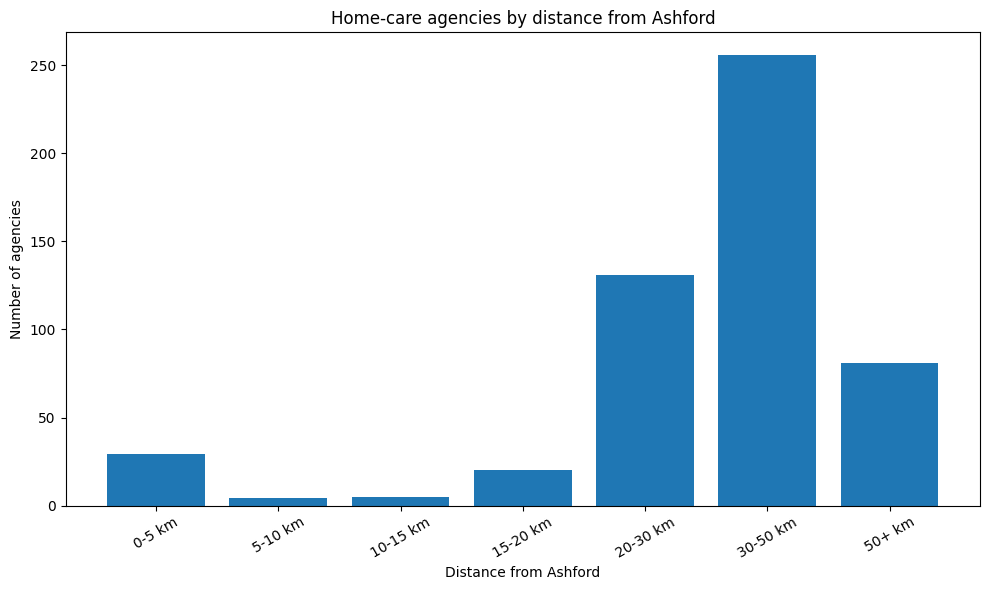

In [199]:
import matplotlib.pyplot as plt

distance_bands = [
    "0-5 km",
    "5-10 km",
    "10-15 km",
    "15-20 km",
    "20-30 km",
    "30-50 km",
    "50+ km"
]

distance_counts = (
    df[
        "ashford_distance_band"
    ]
    .value_counts()
    .reindex(
        distance_bands,
        fill_value=0
    )
)


plt.figure(
    figsize=(10, 6)
)

plt.bar(
    distance_counts.index,
    distance_counts.values
)

plt.title(
    "Home-care agencies by distance from Ashford"
)

plt.xlabel(
    "Distance from Ashford"
)

plt.ylabel(
    "Number of agencies"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.savefig(
    "02_competitors_by_ashford_distance.png",
    dpi=300
)

plt.show()

### Distance summary

In [201]:
distance_summary = pd.DataFrame({
    "competitors": distance_counts,
})

distance_summary["percentage"] = (
    distance_summary["competitors"]
    / distance_summary["competitors"].sum()
    * 100
)

print(distance_summary)

                       competitors  percentage
ashford_distance_band                         
0-5 km                          29    5.513308
5-10 km                          4    0.760456
10-15 km                         5    0.950570
15-20 km                        20    3.802281
20-30 km                       131   24.904943
30-50 km                       256   48.669202
50+ km                          81   15.399240


### Rating dsitribution

In [202]:
rating_counts = (
    df["currentRatings.overall.rating"]
    .fillna("Not rated")
    .replace("", "Not rated")
    .value_counts()
)

print(rating_counts)

currentRatings.overall.rating
Not rated               307
Good                    171
Requires improvement     39
Outstanding               9
Name: count, dtype: int64


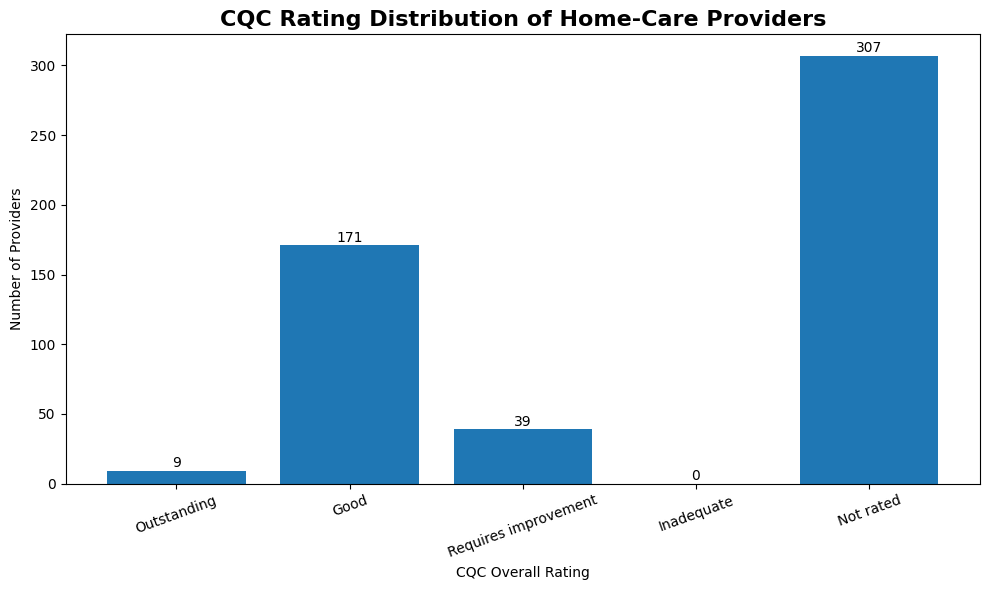

In [203]:
# Put ratings in a meaningful order
rating_order = [
    "Outstanding",
    "Good",
    "Requires improvement",
    "Inadequate",
    "Not rated"
]

rating_counts = (
    df["currentRatings.overall.rating"]
    .fillna("Not rated")
    .replace("", "Not rated")
    .value_counts()
    .reindex(rating_order, fill_value=0)
)

# Plot
plt.figure(figsize=(10, 6))

bars = plt.bar(
    rating_counts.index,
    rating_counts.values
)

plt.title(
    "CQC Rating Distribution of Home-Care Providers",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("CQC Overall Rating")
plt.ylabel("Number of Providers")

plt.xticks(rotation=20)

# Add counts
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        str(int(height)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "03_cqc_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Rating Interactive Map

In [204]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------

df = pd.read_parquet("homecare_market.parquet")

print("Dataset shape:", df.shape)

# Keep providers with coordinates
map_df = df.dropna(
    subset=["latitude", "longitude"]
).copy()

print("Providers with coordinates:", len(map_df))


# ---------------------------------------------------------
# 2. CARTO API KEY
# ---------------------------------------------------------

CARTO_KEY = secrets.get("CARTO_KEY")


# ---------------------------------------------------------
# 3. ASHFORD CENTRE
# ---------------------------------------------------------

ASHFORD_LAT = 51.1465
ASHFORD_LON = 0.8664


# ---------------------------------------------------------
# 4. CREATE MAP
# ---------------------------------------------------------

m = folium.Map(
    location=[ASHFORD_LAT, ASHFORD_LON],
    zoom_start=10,
    control_scale=True
)


# ---------------------------------------------------------
# 5. CARTO BASEMAPS
# ---------------------------------------------------------

folium.TileLayer(
    tiles=(
        "https://basemaps.cartocdn.com/"
        "rastertiles/voyager/{z}/{x}/{y}.png"
        f"?key={CARTO_KEY}"
    ),
    attr=(
        '© <a href="https://www.openstreetmap.org/copyright">'
        'OpenStreetMap</a> contributors, '
        '© <a href="https://carto.com/attribution/">CARTO</a>'
    ),
    name="CARTO Voyager",
    max_zoom=20
).add_to(m)


folium.TileLayer(
    tiles=(
        "https://basemaps.cartocdn.com/"
        "rastertiles/light_all/{z}/{x}/{y}.png"
        f"?key={CARTO_KEY}"
    ),
    attr=(
        '© <a href="https://www.openstreetmap.org/copyright">'
        'OpenStreetMap</a> contributors, '
        '© <a href="https://carto.com/attribution/">CARTO</a>'
    ),
    name="CARTO Positron",
    max_zoom=20
).add_to(m)


# ---------------------------------------------------------
# 6. ASHFORD MARKER
# ---------------------------------------------------------

ashford_layer = folium.FeatureGroup(
    name="Ashford centre",
    show=True
)

folium.Marker(
    [ASHFORD_LAT, ASHFORD_LON],
    popup="<b>Ashford Town Centre</b>",
    tooltip="Ashford"
).add_to(ashford_layer)

ashford_layer.add_to(m)


# ---------------------------------------------------------
# 7. CATCHMENT RINGS
# ---------------------------------------------------------

catchment_layer = folium.FeatureGroup(
    name="Ashford catchment zones",
    show=True
)

for radius in [5, 10, 20, 30]:

    folium.Circle(
        location=[
            ASHFORD_LAT,
            ASHFORD_LON
        ],
        radius=radius * 1000,
        fill=False,
        weight=2,
        dash_array="6,6",
        tooltip=f"{radius} km from Ashford"
    ).add_to(catchment_layer)

catchment_layer.add_to(m)


# ---------------------------------------------------------
# 8. RATING LAYERS
# ---------------------------------------------------------

rating_layers = {
    "Outstanding": folium.FeatureGroup(
        name="CQC — Outstanding",
        show=True
    ),
    "Good": folium.FeatureGroup(
        name="CQC — Good",
        show=True
    ),
    "Requires improvement": folium.FeatureGroup(
        name="CQC — Requires improvement",
        show=True
    ),
    "Inadequate": folium.FeatureGroup(
        name="CQC — Inadequate",
        show=True
    ),
    "Not rated": folium.FeatureGroup(
        name="CQC — Not rated",
        show=True
    )
}


# ---------------------------------------------------------
# 9. RATING COLOURS
# ---------------------------------------------------------

rating_colours = {
    "Outstanding": "green",
    "Good": "blue",
    "Requires improvement": "orange",
    "Inadequate": "red",
    "Not rated": "gray"
}


# ---------------------------------------------------------
# 10. ADD PROVIDERS
# ---------------------------------------------------------

for _, row in map_df.iterrows():

    rating = row.get(
        "currentRatings.overall.rating"
    )

    if pd.isna(rating) or str(rating).strip() == "":
        rating = "Not rated"
    else:
        rating = str(rating).strip()

    # Handle unexpected rating values
    if rating not in rating_layers:
        rating = "Not rated"

    provider_name = row.get(
        "name",
        "Unknown provider"
    )

    postcode = row.get(
        "postalCode",
        "N/A"
    )

    zone = row.get(
        "kent_zone",
        "N/A"
    )

    distance = row.get(
        "distance_from_ashford_km"
    )

    service = row.get(
        "service_type",
        "N/A"
    )

    specialisms = row.get(
        "specialisms_clean",
        "N/A"
    )

    # Distance formatting
    if pd.notna(distance):
        distance_text = f"{distance:.1f} km"
    else:
        distance_text = "N/A"

    popup_html = f"""
    <div style="width:300px">

        <h4 style="margin-bottom:8px;">
            {provider_name}
        </h4>

        <b>CQC rating:</b>
        {rating}<br>

        <b>Postcode:</b>
        {postcode}<br>

        <b>Kent zone:</b>
        {zone}<br>

        <b>Distance from Ashford:</b>
        {distance_text}<br>

        <b>Service:</b>
        {service}<br>

        <b>Specialisms:</b>
        {specialisms}

    </div>
    """

    folium.CircleMarker(
        location=[
            row["latitude"],
            row["longitude"]
        ],
        radius=7,
        color=rating_colours[rating],
        fill=True,
        fill_color=rating_colours[rating],
        fill_opacity=0.75,
        weight=1,
        popup=folium.Popup(
            popup_html,
            max_width=350
        ),
        tooltip=(
            f"{provider_name} — {rating}"
        )
    ).add_to(
        rating_layers[rating]
    )


# ---------------------------------------------------------
# 11. ADD RATING LAYERS TO MAP
# ---------------------------------------------------------

for layer in rating_layers.values():
    layer.add_to(m)


# ---------------------------------------------------------
# 12. LEGEND
# ---------------------------------------------------------

legend_html = """
<div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    width: 210px;
    z-index: 9999;
    background-color: white;
    border: 2px solid #555;
    padding: 12px;
    font-size: 13px;
">

<b>CQC Overall Rating</b><br><br>

<span style="
    color:green;
    font-size:18px;
">●</span>
Outstanding<br>

<span style="
    color:blue;
    font-size:18px;
">●</span>
Good<br>

<span style="
    color:orange;
    font-size:18px;
">●</span>
Requires improvement<br>

<span style="
    color:red;
    font-size:18px;
">●</span>
Inadequate<br>

<span style="
    color:gray;
    font-size:18px;
">●</span>
Not rated

</div>
"""

m.get_root().html.add_child(
    folium.Element(legend_html)
)


# ---------------------------------------------------------
# 13. LAYER CONTROL
# ---------------------------------------------------------

folium.LayerControl(
    collapsed=False
).add_to(m)


# ---------------------------------------------------------
# 14. SAVE
# ---------------------------------------------------------

output_file = "04_ashford_cqc_rating_map.html"

m.save(output_file)

print(f"Map saved to: {output_file}")

Dataset shape: (526, 35)
Providers with coordinates: 526
Map saved to: 04_ashford_cqc_rating_map.html


### Competitor Density Heatmap

In [206]:
import pandas as pd
import folium
from folium.plugins import HeatMap

# ---------------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------------

df = pd.read_parquet("homecare_market.parquet")

map_df = df.dropna(
    subset=["latitude", "longitude"]
).copy()

print("Providers:", len(map_df))


# ---------------------------------------------------------
# 2. ASHFORD CENTRE
# ---------------------------------------------------------

ASHFORD_LAT = 51.1465
ASHFORD_LON = 0.8664


# ---------------------------------------------------------
# 3. CARTO API KEY
# ---------------------------------------------------------

CARTO_KEY = secrets.get("CARTO_KEY")


# ---------------------------------------------------------
# 4. CREATE MAP
# ---------------------------------------------------------

m = folium.Map(
    location=[ASHFORD_LAT, ASHFORD_LON],
    zoom_start=10,
    control_scale=True
)


# ---------------------------------------------------------
# 5. CARTO BASEMAP
# ---------------------------------------------------------

folium.TileLayer(
    tiles=(
        "https://basemaps.cartocdn.com/"
        "rastertiles/voyager/{z}/{x}/{y}.png"
        f"?key={CARTO_KEY}"
    ),
    attr=(
        '© <a href="https://www.openstreetmap.org/copyright">'
        'OpenStreetMap</a> contributors, '
        '© <a href="https://carto.com/attribution/">CARTO</a>'
    ),
    name="CARTO Voyager",
    max_zoom=20
).add_to(m)


# ---------------------------------------------------------
# 6. ASHFORD CATCHMENT
# ---------------------------------------------------------

catchment_layer = folium.FeatureGroup(
    name="Ashford catchment",
    show=True
)

for radius in [5, 10, 20, 30]:

    folium.Circle(
        location=[
            ASHFORD_LAT,
            ASHFORD_LON
        ],
        radius=radius * 1000,
        fill=False,
        weight=2,
        dash_array="6,6",
        tooltip=f"{radius} km from Ashford"
    ).add_to(catchment_layer)

catchment_layer.add_to(m)


# ---------------------------------------------------------
# 7. ASHFORD MARKER
# ---------------------------------------------------------

folium.Marker(
    [ASHFORD_LAT, ASHFORD_LON],
    popup="<b>Ashford Town Centre</b>",
    tooltip="Ashford"
).add_to(m)


# ---------------------------------------------------------
# 8. COMPETITOR HEATMAP
# ---------------------------------------------------------

heat_layer = folium.FeatureGroup(
    name="Competitor density",
    show=True
)

heat_data = (
    map_df[
        ["latitude", "longitude"]
    ]
    .values
    .tolist()
)

HeatMap(
    heat_data,
    radius=22,
    blur=28,
    min_opacity=0.30,
    max_zoom=12
).add_to(heat_layer)

heat_layer.add_to(m)


# ---------------------------------------------------------
# 9. OPTIONAL: INDIVIDUAL PROVIDERS
# ---------------------------------------------------------

provider_layer = folium.FeatureGroup(
    name="Individual providers",
    show=False
)

for _, row in map_df.iterrows():

    rating = row.get(
        "currentRatings.overall.rating",
        "Not rated"
    )

    provider_name = row.get(
        "name",
        "Unknown provider"
    )

    distance = row.get(
        "distance_from_ashford_km"
    )

    if pd.notna(distance):
        distance_text = f"{distance:.1f} km"
    else:
        distance_text = "N/A"

    popup_html = f"""
    <b>{provider_name}</b><br>
    CQC rating: {rating}<br>
    Postcode: {row.get('postalCode', 'N/A')}<br>
    Zone: {row.get('kent_zone', 'N/A')}<br>
    Distance from Ashford: {distance_text}
    """

    folium.CircleMarker(
        location=[
            row["latitude"],
            row["longitude"]
        ],
        radius=4,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            popup_html,
            max_width=300
        )
    ).add_to(provider_layer)

provider_layer.add_to(m)


# ---------------------------------------------------------
# 10. LAYER CONTROL
# ---------------------------------------------------------

folium.LayerControl(
    collapsed=False
).add_to(m)


# ---------------------------------------------------------
# 11. SAVE
# ---------------------------------------------------------

output_file = "05_ashford_competitor_density_map.html"

m.save(output_file)

print(f"Saved: {output_file}")

Providers: 526
Saved: 05_ashford_competitor_density_map.html


### Competitors by Zone

In [207]:
zone_order = [
    "South Kent",
    "East Kent",
    "Mid Kent",
    "West Kent",
    "North Kent",
    "Medway"
]

zone_counts = (
    df["kent_zone"]
    .fillna("Unknown")
    .value_counts()
    .reindex(zone_order, fill_value=0)
)

print(zone_counts)

kent_zone
South Kent    34
East Kent     41
Mid Kent      50
West Kent     28
North Kent    62
Medway         1
Name: count, dtype: int64


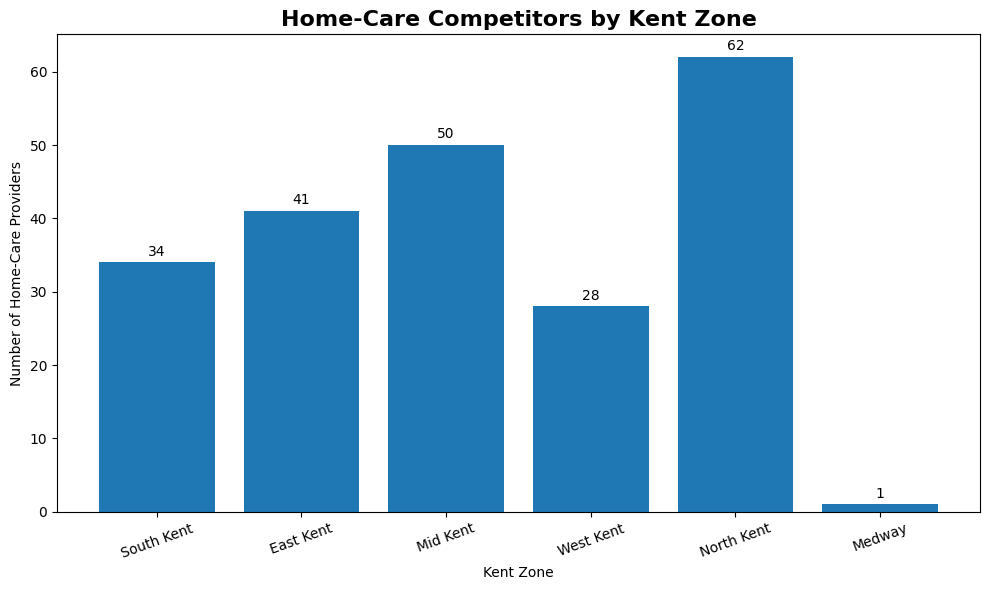

In [208]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    zone_counts.index,
    zone_counts.values
)

plt.title(
    "Home-Care Competitors by Kent Zone",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Kent Zone")
plt.ylabel("Number of Home-Care Providers")

plt.xticks(rotation=20)

# Add values above bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        str(int(height)),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "06_homecare_competitors_by_kent_zone.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Rating Profile by Zone

In [209]:

df["cqc_rating"] = (
    df["currentRatings.overall.rating"]
    .fillna("Not rated")
    .replace("", "Not rated")
    .astype(str)
    .str.strip()
)

print(df["cqc_rating"].value_counts())

cqc_rating
Not rated               307
Good                    171
Requires improvement     39
Outstanding               9
Name: count, dtype: int64


In [210]:
zone_order = [
    "South Kent",
    "East Kent",
    "Mid Kent",
    "West Kent",
    "North Kent",
    "Medway"
]

rating_order = [
    "Outstanding",
    "Good",
    "Requires improvement",
    "Inadequate",
    "Not rated"
]

In [211]:
rating_by_zone = pd.crosstab(
    df["kent_zone"],
    df["cqc_rating"],
    normalize="index"
) * 100

rating_by_zone = rating_by_zone.reindex(
    index=zone_order,
    columns=rating_order,
    fill_value=0
)

print(rating_by_zone.round(1))

cqc_rating  Outstanding  Good  Requires improvement  Inadequate  Not rated
kent_zone                                                                 
South Kent          0.0  32.4                  17.6         0.0       50.0
East Kent           2.4  36.6                   0.0         0.0       61.0
Mid Kent            2.0  32.0                   6.0         0.0       60.0
West Kent           3.6  46.4                   7.1         0.0       42.9
North Kent          0.0  25.8                   3.2         0.0       71.0
Medway              0.0   0.0                   0.0         0.0      100.0


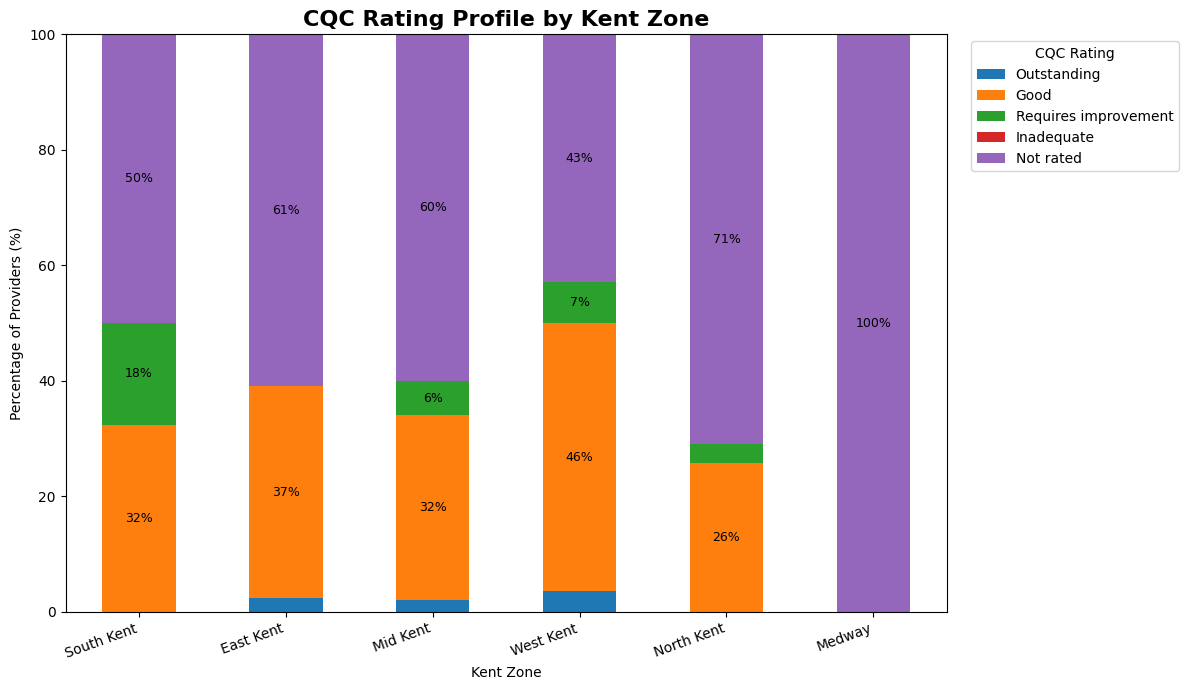

In [212]:
fig, ax = plt.subplots(figsize=(12, 7))

rating_by_zone.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title(
    "CQC Rating Profile by Kent Zone",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Kent Zone")
ax.set_ylabel("Percentage of Providers (%)")

ax.set_ylim(0, 100)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=20,
    ha="right"
)

ax.legend(
    title="CQC Rating",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Add percentage labels where meaningful
for i, zone in enumerate(rating_by_zone.index):

    cumulative = 0

    for rating in rating_order:

        value = rating_by_zone.loc[
            zone,
            rating
        ]

        if value >= 5:

            ax.text(
                i,
                cumulative + value / 2,
                f"{value:.0f}%",
                ha="center",
                va="center",
                fontsize=9
            )

        cumulative += value

plt.tight_layout()

plt.savefig(
    "07_cqc_rating_profile_by_zone.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [213]:
rating_by_zone.round(2).to_csv(
    "07_cqc_rating_profile_by_zone.csv"
)

print(
    "Saved: 07_cqc_rating_profile_by_zone.csv"
)

Saved: 07_cqc_rating_profile_by_zone.csv
